# Monte Carlo Policy Gradient

In [1]:
import gymnasium as gym
import numpy as np
import torch
import gymnasium as gym
from matplotlib import pyplot as plt


env = gym.make("CartPole-v1")

# The reset method initializes the environment and returns the first state.
state1, info = env.reset()
action = env.action_space.sample()
# The step method returns four important variables 
# that our training loop needs access to in order to run.
state2, reward, terminated, truncated, info = env.step(action)

In [2]:
def discount_rewards(rewards, gamma=0.99):
    lenr = len(rewards)
    disc_return = torch.pow(gamma, torch.arange(lenr)) * rewards
    disc_return /= disc_return.max()
    return disc_return

def loss_fn(preds, r):
    return - torch.sum(r * torch.log(preds))


In [3]:
l1 = 4
l2 = 100
l3 = 2

model = torch.nn.Sequential(
    torch.nn.Linear(l1, l2),
    torch.nn.LeakyReLU(),
    torch.nn.Linear(l2, l3),
    torch.nn.Softmax(dim=0)
)

learning_rate = 0.009
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)


In [4]:
MAX_EPISODES = 500
gamma = 0.99
MAX_DURATION = 200

score = []

In [5]:
for i in range(MAX_EPISODES):
    state1, _ = env.reset()
    done = False
    transitions = []

    for t in range(MAX_DURATION):
        action_probs = model(torch.from_numpy(state1).float()) # model require torch
        action = np.random.choice(np.array([0,1]), p=action_probs.detach().numpy())
        state2, reward, done, _, _ = env.step(action)
        transitions.append((state1, action, t+1))
        state1 = state2
        if done:
            break

    ep_len = len(transitions)
    score.append(ep_len)
    reward_batch = torch.Tensor([r for (s,a,r) in transitions]).flip(dims=(0,))
    disc_reward = discount_rewards(reward_batch, gamma)
    state_batch = torch.Tensor(np.array([s for (s,a,r) in transitions]))
    action_batch = torch.Tensor([a for (s,a,r) in transitions])

    pred_batch = model(state_batch)
    # squeeze [T,1] -> [T] 让 r * log(prob) 是逐步元素相乘，保留 per-step credit assignment
    prob_batch = pred_batch.gather(dim=-1, index=action_batch.long().view(-1,1)).squeeze()

    loss = loss_fn(prob_batch, disc_reward)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


In [6]:
score = np.array(score)
avg_score = np.convolve(score, np.ones(50) / 50, mode='valid')

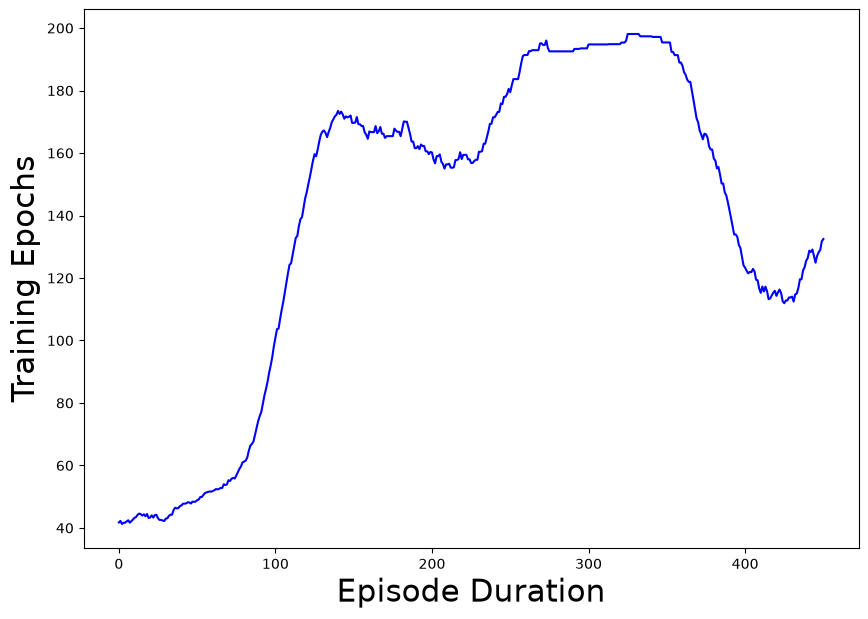

In [7]:
plt.figure(figsize=(10,7))
plt.xlabel("Episode Duration",fontsize=22)
plt.ylabel("Training Epochs",fontsize=22)
plt.plot(avg_score, color='blue')

In [8]:
# 用 render_mode="human" 打开可视化窗口，跑几局看训练好的策略表现
render_env = gym.make("CartPole-v1", render_mode="human")

N_EPISODES = 5
for ep in range(N_EPISODES):
    state, _ = render_env.reset()
    done = False
    truncated = False
    total = 0
    while not (done or truncated):
        with torch.no_grad():
            probs = model(torch.from_numpy(state).float())
        action = int(torch.argmax(probs).item())  # greedy: 用 np.random.choice 采样也行
        state, reward, done, truncated, _ = render_env.step(action)
        total += reward
    print(f"episode {ep+1}: return = {total}")

render_env.close()


episode 1: return = 500.0
episode 2: return = 500.0
episode 3: return = 500.0
episode 4: return = 500.0
episode 5: return = 500.0
